In [1]:
# Install Kaggle API if not already installed
!pip install kaggle

# Upload kaggle.json manually if not done already
from google.colab import files
print("Please upload your kaggle.json file (make sure it's named kaggle.json).")
uploaded = files.upload()  # Upload kaggle.json file manually when prompted

# Move kaggle.json to correct location
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

# Now use the Kaggle API to download the dataset
!kaggle datasets download -d atulyakumar98/pothole-detection-dataset --force

# Unzip the downloaded dataset
!unzip -q pothole-detection-dataset.zip -d /content/pothole_detection_data

# Verify the contents of the dataset directory
import os
dataset_dir = '/content/pothole_detection_data'
if os.path.exists(dataset_dir):
    print("Files in dataset directory:", os.listdir(dataset_dir))
else:
    print("Dataset directory not found; please check if the dataset downloaded correctly.")

Please upload your kaggle.json file (make sure it's named kaggle.json).


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/atulyakumar98/pothole-detection-dataset
License(s): CC0-1.0
100% 193M/194M [00:01<00:00, 187MB/s]
100% 194M/194M [00:01<00:00, 184MB/s]
Files in dataset directory: ['normal', 'potholes']


Error reading image: /content/pothole_detection_data/normal/226.jpg
Training Set Metrics:
Accuracy: 0.8107
Precision: 0.7993
Recall: 0.8423
F1 Score: 0.8202

Testing Set Metrics:
Accuracy: 0.6765
Precision: 0.5405
Recall: 0.8000
F1 Score: 0.6452


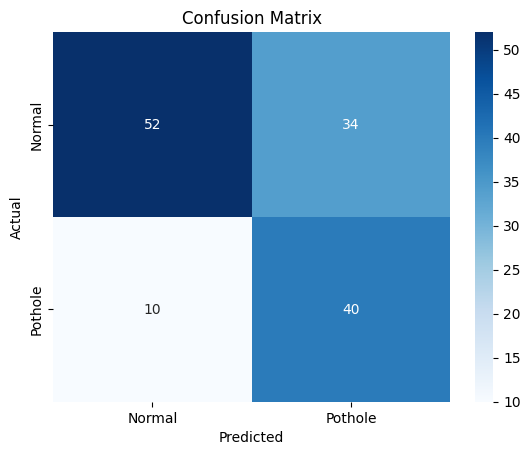

In [3]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Define paths for your dataset
normal_dir = '/content/pothole_detection_data/normal'
pothole_dir = '/content/pothole_detection_data/potholes'

# Load images and labels
def load_images_and_labels(normal_dir, pothole_dir, image_size=(64, 64)):
    images = []
    labels = []

    # Load normal images (label = 0)
    for img_name in os.listdir(normal_dir):
        img_path = os.path.join(normal_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Error reading image: {img_path}")
            continue  # Skip this image if it cannot be loaded
        img = cv2.resize(img, image_size)  # Resize to a consistent size
        images.append(img)
        labels.append(0)  # Label 0 for 'normal'

    # Load pothole images (label = 1)
    for img_name in os.listdir(pothole_dir):
        img_path = os.path.join(pothole_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Error reading image: {img_path}")
            continue  # Skip this image if it cannot be loaded
        img = cv2.resize(img, image_size)  # Resize to a consistent size
        images.append(img)
        labels.append(1)  # Label 1 for 'pothole'

    images = np.array(images)
    labels = np.array(labels)

    # Flatten the images to 1D arrays (KNN requires 1D feature vectors)
    images = images.reshape(images.shape[0], -1)
    return images, labels

# Load and preprocess the data
X, y = load_images_and_labels(normal_dir, pothole_dir)

# Normalize the images to [0, 1]
X = X / 255.0

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data (optional, improves KNN performance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can tune this hyperparameter

# Train the model
knn.fit(X_train, y_train)

# Make predictions on both training and test sets
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

# Evaluate the model using multiple metrics on training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='binary')
train_recall = recall_score(y_train, y_train_pred, average='binary')
train_f1 = f1_score(y_train, y_train_pred, average='binary')

# Evaluate the model using multiple metrics on test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='binary')
test_recall = recall_score(y_test, y_test_pred, average='binary')
test_f1 = f1_score(y_test, y_test_pred, average='binary')

# Print evaluation metrics for training set
print("Training Set Metrics:")
print(f"Accuracy: {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall: {train_recall:.4f}")
print(f"F1 Score: {train_f1:.4f}")

# Print evaluation metrics for testing set
print("\nTesting Set Metrics:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# Plot confusion matrix for test set
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pothole'], yticklabels=['Normal', 'Pothole'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

